<a href="https://colab.research.google.com/github/muskan2109/FML_Practicals/blob/main/Task7_EE510.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**K Mean**



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [20]:
file = "wireless_signal_kmeans_dataset.csv"

In [14]:
if len(data.columns) == 1:

    data = data.iloc[:,0].str.split(
        ",",
        expand=True
    )


In [15]:

data.columns = [
        "RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]


In [16]:
data.columns = data.columns.str.strip()

In [17]:
print("\nDataset Columns:")
print(data.columns)


print("\nDataset Preview:")
print(data.head())

data = data.dropna()



Dataset Columns:
Index(['RSSI', 'RSRP', 'RSRQ', 'SNR', 'Latency', 'Packet_Loss'], dtype='object')

Dataset Preview:
  RSSI RSRP RSRQ SNR Latency Packet_Loss
0  -45  -75   -5  30      10           1
1  -48  -78   -6  28      12           1
2  -50  -80   -7  27      15           2
3  -52  -82   -8  25      18           2
4  -55  -85   -9  23      20           3


In [21]:
for col in data.columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )


In [22]:
data.dropna(inplace=True)

print("\nClean Dataset:")
print(data.head())



Clean Dataset:
   RSSI  RSRP  RSRQ  SNR  Latency  Packet_Loss
0   -45   -75    -5   30       10            1
1   -48   -78    -6   28       12            1
2   -50   -80    -7   27       15            2
3   -52   -82    -8   25       18            2
4   -55   -85    -9   23       20            3


In [23]:
X = data[
    [
        "RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]
]


scaler = StandardScaler()


In [24]:
X_scaled = scaler.fit_transform(
    X
)


kmeans = KMeans(

    n_clusters=3,

    random_state=42,

    n_init=10

)

data["Cluster"] = kmeans.fit_predict(
    X_scaled
)


In [25]:
print("\nCluster Count:")
print(
    data["Cluster"].value_counts()
)

cluster_strength = data.groupby(
    "Cluster"
)["RSSI"].mean()

print("\nAverage RSSI:")
print(cluster_strength)



Cluster Count:
Cluster
0    11
2    10
1     8
Name: count, dtype: int64

Average RSSI:
Cluster
0   -64.090909
1   -76.000000
2   -50.500000
Name: RSSI, dtype: float64


In [ ]:
sorted_cluster = cluster_strength.sort_values(
    ascending=False
)


quality = {

    sorted_cluster.index[0]: "Good",

    sorted_cluster.index[1]: "Medium",

    sorted_cluster.index[2]: "Poor"

}


In [ ]:
data["Signal_Quality"] = data["Cluster"].map(
    quality
)

print("\nSignal Quality Groups:")
print(
    data[
        [
            "RSSI",
            "Cluster",
            "Signal_Quality"
        ]
    ]
)



Signal Quality Groups:
    RSSI  Cluster Signal_Quality
0    -45        2           Good
1    -48        2           Good
2    -50        2           Good
3    -52        2           Good
4    -55        2           Good
5    -58        0         Medium
6    -60        0         Medium
7    -62        0         Medium
8    -65        0         Medium
9    -68        0         Medium
10   -70        0         Medium
11   -72        1           Poor
12   -75        1           Poor
13   -78        1           Poor
14   -80        1           Poor
15   -47        2           Good
16   -54        2           Good
17   -59        0         Medium
18   -64        0         Medium
19   -69        0         Medium
20   -74        1           Poor
21   -79        1           Poor
22   -46        2           Good
23   -51        2           Good
24   -57        2           Good
25   -63        0         Medium
26   -67        0         Medium
27   -73        1           Poor
28   -77        1  

In [ ]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Axes: >

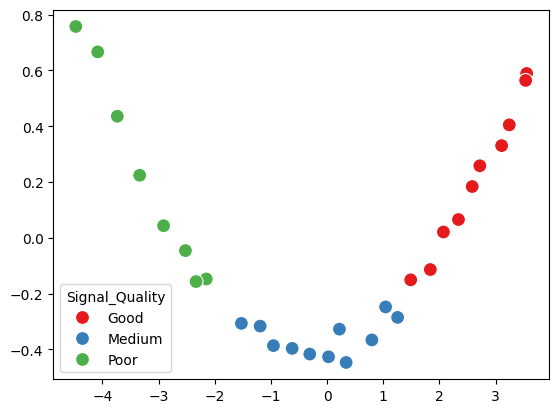

In [ ]:
sns.scatterplot(

    x=X_pca[:,0],

    y=X_pca[:,1],

    hue=data["Signal_Quality"],

    palette="Set1",

    s=100

)


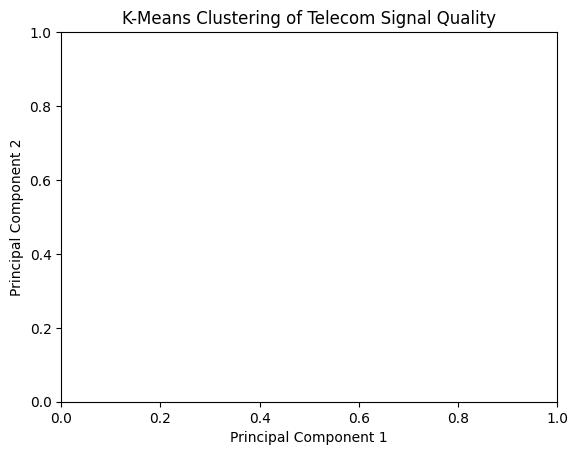

In [ ]:
plt.title(
    "K-Means Clustering of Telecom Signal Quality"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()


In [ ]:

centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)


print("\nCluster Centers:")


print(
    pd.DataFrame(
        centers,
        columns=X.columns
    )
)



Cluster Centers:
        RSSI        RSRP       RSRQ     SNR    Latency  Packet_Loss
0 -64.090909  -94.090909 -12.363636  15.000  42.818182     7.636364
1 -76.000000 -106.000000 -17.125000   5.625  98.750000    19.375000
2 -50.500000  -80.500000  -7.000000  26.400  15.400000     2.000000


In [ ]:
X = data[
    [
        "RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]
]



In [ ]:
new_scaled = scaler.transform(
    new_signal
)

cluster = kmeans.predict(
    new_scaled
)

print("\nNew Signal Cluster:")
print(cluster[0])
print(
    "Signal Quality:",
    quality[cluster[0]]
)



New Signal Cluster:
2
Signal Quality: Good
